# Real Estate EDA and Feature Improvement Notebook

Use this notebook to inspect skew, review the transformed feature set, and compare model quality before and after feature improvements.

In [23]:
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

from src.training.evaluate import evaluate_regression_model

In [24]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [37]:
feature_path = Path('../data/processed/california_housing_features.csv')
feature_df = pd.read_csv(feature_path)
feature_df.head()

,median_income,house_age,average_rooms,average_bedrooms,population,average_occupancy,latitude,longitude,median_house_value,bedroom_ratio,...,log_population,population_capped,log_average_occupancy,average_occupancy_capped,log_average_rooms,average_rooms_capped,log_average_bedrooms,average_bedrooms_capped,log_rooms_per_person,rooms_per_person_capped
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0.146591,...,5.777652,322.0,1.268511,2.555556,2.077455,6.984127,0.704982,1.023810,1.317191,2.732919
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.155797,...,7.784057,2401.0,1.134572,2.109842,1.979364,6.238137,0.678988,0.971880,1.375406,2.956685
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.129516,...,6.208590,496.0,1.335596,2.802260,2.228738,8.288136,0.729212,1.073446,1.375653,2.957661
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0.184458,...,6.326149,558.0,1.266369,2.547945,1.919471,5.817352,0.729025,1.073059,1.188805,2.283154
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0.172096,...,6.338594,565.0,1.157342,2.181467,1.985385,6.281853,0.732888,1.081081,1.355744,2.879646


## Summary and skew

In [38]:
feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
house_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
average_rooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
average_bedrooms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
average_occupancy,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
median_house_value,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010
bedroom_ratio,20640.0,0.213075,0.058023,0.100000,0.175426,0.203181,0.239834,1.000000


In [39]:
feature_df.skew(numeric_only=True).sort_values(ascending=False).to_frame('skew')

,skew
average_occupancy,97.639561
average_bedrooms,31.316956
average_rooms,20.697869
rooms_per_person,17.775133
log_average_bedrooms,8.988786
population,4.935858
average_bedrooms_capped,4.021616
log_average_occupancy,3.879679
bedroom_ratio,2.246891
population_capped,1.952252


## Compare original vs transformed distributions

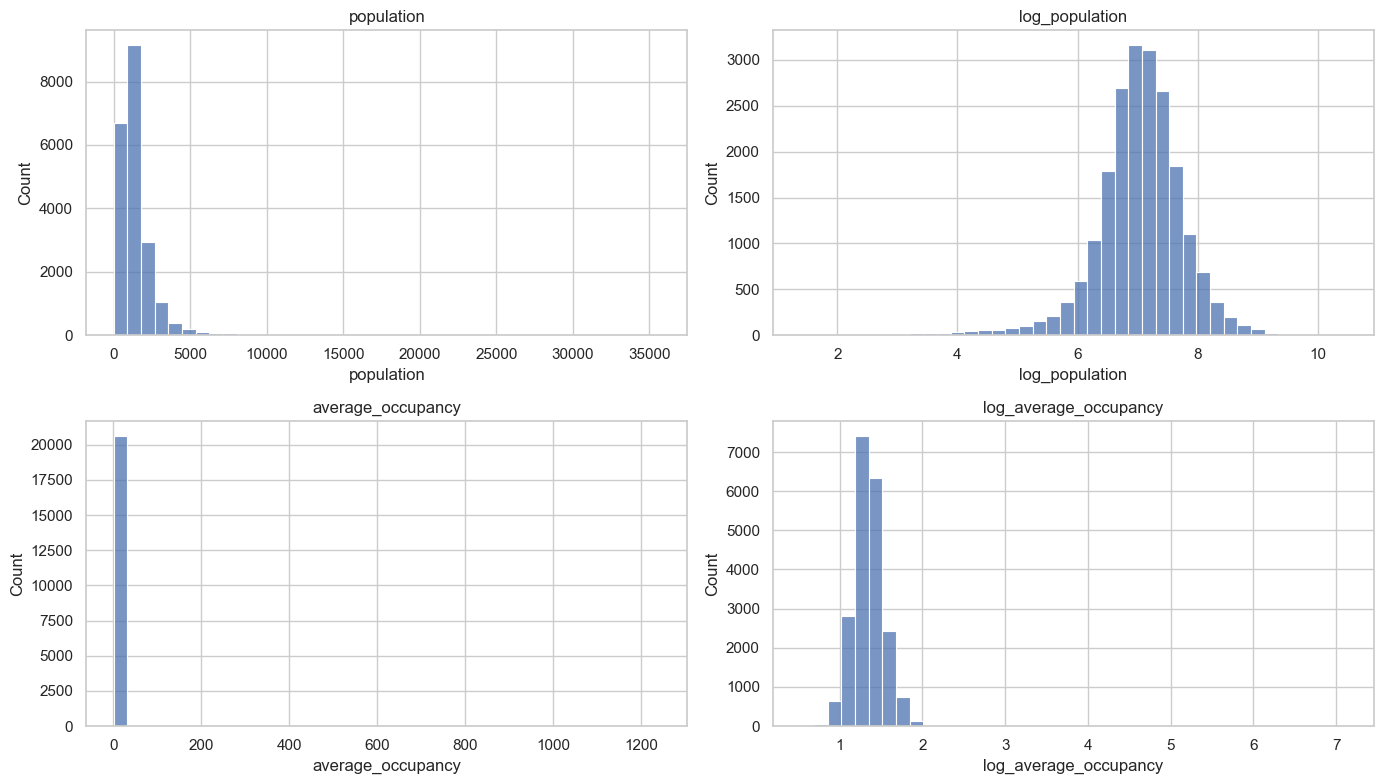

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.histplot(feature_df['population'], bins=40, ax=axes[0, 0])
axes[0, 0].set_title('population')
sns.histplot(feature_df['log_population'], bins=40, ax=axes[0, 1])
axes[0, 1].set_title('log_population')
sns.histplot(feature_df['average_occupancy'], bins=40, ax=axes[1, 0])
axes[1, 0].set_title('average_occupancy')
sns.histplot(feature_df['log_average_occupancy'], bins=40, ax=axes[1, 1])
axes[1, 1].set_title('log_average_occupancy')
plt.tight_layout()

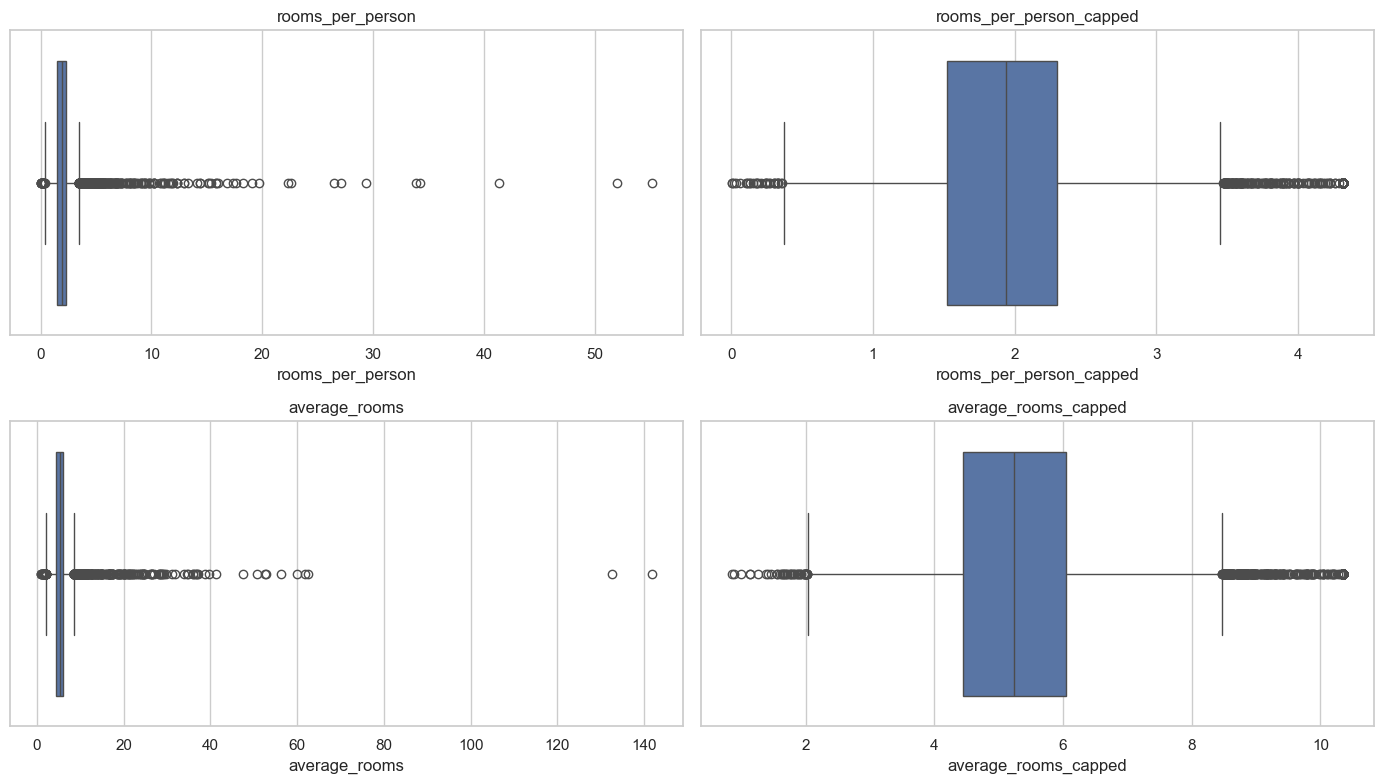

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.boxplot(x=feature_df['rooms_per_person'], ax=axes[0, 0])
axes[0, 0].set_title('rooms_per_person')
sns.boxplot(x=feature_df['rooms_per_person_capped'], ax=axes[0, 1])
axes[0, 1].set_title('rooms_per_person_capped')
sns.boxplot(x=feature_df['average_rooms'], ax=axes[1, 0])
axes[1, 0].set_title('average_rooms')
sns.boxplot(x=feature_df['average_rooms_capped'], ax=axes[1, 1])
axes[1, 1].set_title('average_rooms_capped')
plt.tight_layout()

## Correlation with target

In [42]:
feature_df.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False).to_frame('target_correlation')

,target_correlation
median_house_value,1.000000
median_income,0.688075
rooms_per_person_capped,0.394224
log_rooms_per_person,0.353401
average_rooms_capped,0.293026
log_average_rooms,0.241034
rooms_per_person,0.209482
average_rooms,0.151948
house_age,0.105623
log_population,-0.021205


## Model comparison on improved features

In [43]:
X = feature_df.drop(columns=['median_house_value'])
y = feature_df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)


In [44]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_metrics = evaluate_regression_model(y_test, linear_model.predict(X_test))
linear_metrics

{'rmse': 0.6618477412152375,
 'mae': 0.4784395646469093,
 'r2': 0.6657208247002836}

In [45]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=16,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_metrics = evaluate_regression_model(y_test, rf_model.predict(X_test))
rf_metrics

{'rmse': 0.5058394908754563,
 'mae': 0.32964661160645775,
 'r2': 0.8047376088092535}

In [46]:
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
xgb_metrics = evaluate_regression_model(y_test, xgb_model.predict(X_test))
xgb_metrics

{'rmse': 0.45081405759959836,
 'mae': 0.2961721411503817,
 'r2': 0.8449084843708599}

In [47]:
pd.DataFrame(
    {
        'linear_regression': linear_metrics,
        'random_forest': rf_metrics,
        'xgboost': xgb_metrics,
    }
)

,linear_regression,random_forest,xgboost
rmse,0.661848,0.505839,0.450814
mae,0.478440,0.329647,0.296172
r2,0.665721,0.804738,0.844908


In [48]:
# Step 2: Create final clean feature set for XGBoost

target_col = "median_house_value"

# Keep stable/original useful features
base_features = [
    "median_income",
    "house_age",
    "latitude",
    "longitude",
    "bedroom_ratio",
]

# Use capped/log versions for highly skewed columns
engineered_features = [
    "average_rooms_capped",
    "average_bedrooms_capped",
    "average_occupancy_capped",
    "rooms_per_person_capped",
    "population_capped",
    "log_population",
    "log_average_rooms",
    "log_average_occupancy",
    "log_rooms_per_person",
]

final_features = base_features + engineered_features

# Create final modeling dataframe
model_df = feature_df[final_features + [target_col]].copy()

print("Final model dataframe shape:", model_df.shape)
print("\nFinal features used:")
for i, col in enumerate(final_features, start=1):
    print(f"{i}. {col}")

print("\nMissing values:")
display(model_df.isnull().sum())

print("\nDuplicate rows:", model_df.duplicated().sum())

display(model_df.describe().T)

Final model dataframe shape: (20640, 15)

Final features used:
1. median_income
2. house_age
3. latitude
4. longitude
5. bedroom_ratio
6. average_rooms_capped
7. average_bedrooms_capped
8. average_occupancy_capped
9. rooms_per_person_capped
10. population_capped
11. log_population
12. log_average_rooms
13. log_average_occupancy
14. log_rooms_per_person

Missing values:


median_income               0
house_age                   0
latitude                    0
longitude                   0
bedroom_ratio               0
average_rooms_capped        0
average_bedrooms_capped     0
average_occupancy_capped    0
rooms_per_person_capped     0
population_capped           0
log_population              0
log_average_rooms           0
log_average_occupancy       0
log_rooms_per_person        0
median_house_value          0
dtype: int64


Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
house_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
bedroom_ratio,20640.0,0.213075,0.058023,0.100000,0.175426,0.203181,0.239834,1.000000
average_rooms_capped,20640.0,5.330588,1.330038,0.846154,4.440716,5.229129,6.052381,10.357033
average_bedrooms_capped,20640.0,1.076287,0.160058,0.333333,1.006079,1.048780,1.099526,2.127541
average_occupancy_capped,20640.0,2.915167,0.734751,0.692308,2.429741,2.818116,3.282261,5.394812
rooms_per_person_capped,20640.0,1.932365,0.632278,0.002547,1.522382,1.937936,2.296090,4.320205
population_capped,20640.0,1403.613896,973.476399,3.000000,787.000000,1166.000000,1725.000000,5805.830000


In [49]:
# Step 2: Train XGBoost on final clean feature set

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import numpy as np

target_col = "median_house_value"

X = model_df.drop(columns=[target_col])
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

xgb_clean = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_clean.fit(X_train, y_train)

y_pred = xgb_clean.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost on clean feature set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

print("\nOld XGBoost reference:")
print("RMSE: 0.4508")
print("MAE: 0.2961")
print("R²: 0.8449")

XGBoost on clean feature set:
RMSE: 0.4547
MAE: 0.2989
R²: 0.8422

Old XGBoost reference:
RMSE: 0.4508
MAE: 0.2961
R²: 0.8449


In [50]:
# Step 3: Tune XGBoost on clean feature set

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import numpy as np

target_col = "median_house_value"

X = model_df.drop(columns=[target_col])
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

base_xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500, 700, 900],
    "learning_rate": [0.01, 0.03, 0.05, 0.07],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 3],
}

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_

y_pred = best_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best parameters:")
print(search.best_params_)

print("\nTuned XGBoost on clean feature set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

print("\nPrevious clean XGBoost:")
print("RMSE: 0.4547")
print("MAE: 0.2989")
print("R²: 0.8422")

print("\nOld raw-feature XGBoost:")
print("RMSE: 0.4508")
print("MAE: 0.2961")
print("R²: 0.8449")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=7, n_estimators=500, reg_alpha=0.01, reg_lambda=3, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=1.0, learning_rate=0.07, max_depth=3, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.5, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.07, max_depth=3, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.5, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=1.0, learning_rate=0.07, max_depth=3, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.5, subsample=0.7; total time=   0.2s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=7, n_estimators=500, reg_alpha=0.01, reg_lambda=3, subsample=0.7; total time=   0.3s
[CV] END colsample_bytree=0.7, learning_rate=0.07, max_depth=3, min_child_weight=3, n_estimators=700, r

In [51]:
# Step 4: Save final tuned XGBoost model and feature list

import joblib
import json
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

final_model_path = models_dir / "xgboost_price_model_tuned_clean.joblib"
feature_list_path = models_dir / "xgboost_price_model_features.json"
metrics_path = models_dir / "xgboost_price_model_metrics.json"

# Save model
joblib.dump(best_xgb, final_model_path)

# Save feature list in exact training order
feature_names = list(X_train.columns)
with open(feature_list_path, "w") as f:
    json.dump(feature_names, f, indent=4)

# Save metrics
final_metrics = {
    "rmse": round(rmse, 4),
    "mae": round(mae, 4),
    "r2": round(r2, 4),
    "target_unit": "100000 USD",
    "approx_mae_usd": round(mae * 100000, 2),
    "approx_rmse_usd": round(rmse * 100000, 2),
    "best_params": search.best_params_,
}

with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Saved final model to:", final_model_path)
print("Saved feature list to:", feature_list_path)
print("Saved metrics to:", metrics_path)

print("\nFinal metrics:")
print(final_metrics)

Saved final model to: ../models/xgboost_price_model_tuned_clean.joblib
Saved feature list to: ../models/xgboost_price_model_features.json
Saved metrics to: ../models/xgboost_price_model_metrics.json

Final metrics:
{'rmse': np.float64(0.4388), 'mae': 0.2865, 'r2': 0.8531, 'target_unit': '100000 USD', 'approx_mae_usd': 28652.09, 'approx_rmse_usd': np.float64(43879.56), 'best_params': {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 1, 'n_estimators': 900, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.07, 'colsample_bytree': 0.7}}
